# What Drives Emergency Department Wait Times Across U.S. Hospitals?
**BA780 Team Assignment · Cohort A · Team 4**

**Team members:** Hassan Imran Malik (Project Manager) · Aashna Pathi · Michael · Weiran Wang

## Introduction
Emergency department (ED) wait times vary widely across the United States. At some hospitals patients are treated and discharged in under two hours, while at others the typical visit lasts more than five. Long waits are linked to worse patient outcomes and to patients leaving before they are seen.

The aim of this project is to understand **which hospital and community characteristics are associated with longer ED visits**. We combine three public datasets (hospital wait times, hospital characteristics and state economic conditions) into one hospital-level table. The findings are intended for hospital operations leaders deciding where to add capacity and for state health departments deciding where to direct funding.

**Main outcome:** `OP_18b`, the median time (in minutes) patients spend in the ED from arrival to departure, excluding psychiatric and transfer patients. Lower is better.

**Success for this phase:** each dataset cleaned and documented, exploratory questions answered with charts and tables, and the cleaned tables combined into one dataset that is ready for the final analysis.

## Data Sources

| Dataset | Source | Size | Unit of observation | License |
|---|---|---|---|---|
| CMS Timely and Effective Care – Hospital | [data.cms.gov/provider-data/dataset/yv7e-xc69](https://data.cms.gov/provider-data/dataset/yv7e-xc69) | 138,084 rows × 16 columns | Hospital × quality measure | U.S. government public data |
| CMS Hospital General Information | [data.cms.gov/provider-data/dataset/xubh-q36u](https://data.cms.gov/provider-data/dataset/xubh-q36u) | 5,419 rows × 38 columns | Hospital | U.S. government public data |
| U.S. Census ACS 2024 1-Year, Table DP03 (all states) | [data.census.gov/table/ACSDP1Y2024.DP03](https://data.census.gov/table/ACSDP1Y2024.DP03?g=010XX00US$0400000) | 52 rows × 25 columns | State | Public domain |

**Data period:** wait times, stroke and sepsis measures cover Oct 2024 – Sep 2025; ED volume and patients leaving before being seen cover 2024; hospital information is the current CMS release; Census values are 2024 estimates.

**Access:** copies of all three files are stored in our GitHub repository, [github.com/Hassan02052002/ba780-er-wait-times](https://github.com/Hassan02052002/ba780-er-wait-times). The Setup cell loads them directly from there, so the notebook runs in Google Colab or Jupyter with **Restart & Run All** and no downloads.

## Executive Summary
Across 4,081 U.S. hospitals, the typical median ED visit lasts **148 minutes**, and one in ten hospitals exceeds 225 minutes. Location matters: median visit times range from **105 minutes in North Dakota to 328 minutes in Washington, D.C.**, and the fastest states are the rural states that rely most on Critical Access hospitals and have the shortest commutes. Psychiatric patients stay longer than other patients at **92.5% of hospitals**, by a median of 83 minutes. Hospital quality differs by owner: **45.7% of rated non-profit hospitals have 4–5 stars, compared with 28.7% of for-profit hospitals**, while lower-income states such as Texas, Georgia and Oklahoma have the highest uninsured rates. Busier EDs also lose more patients: on average **2.31% of patients leave very-high-volume EDs before being seen, compared with 1.08% at low-volume EDs**. We combined the three cleaned tables into one dataset of 4,080 hospitals; based on these early findings, hospital leaders should prioritize behavioral-health pathways and capacity at high-volume EDs, and the final phase will test which hospital and state characteristics are most closely linked to longer waits.

## Notebook Structure
The project uses three datasets, so this notebook has one section per dataset. Each section follows the same steps: inspect the raw data, clean it (with a cleaning log and before/after summaries), and answer exploratory questions with charts and tables. The final section combines the three cleaned tables into one dataset.

0. **Setup:** libraries and all three datasets, loaded from GitHub
1. **ED Wait Times and Crowding** (CMS Timely and Effective Care) · Charts 1–3
2. **Hospital Characteristics** (CMS Hospital General Information) · Chart 4
3. **State Economic Conditions** (Census ACS DP03) · Chart 5
4. **Combined Dataset**
5. **Conclusion, References and AI Disclosure**

## 0. Setup
Run this cell first. It imports the libraries, loads all three datasets from our GitHub repository and creates the shared cleaning log.

In [1]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

np.random.seed(42)

# All three datasets are stored in our GitHub repository, so the notebook runs anywhere (Colab or Jupyter)
DATA_URL = "https://raw.githubusercontent.com/Hassan02052002/ba780-er-wait-times/main/data/"

# Facility IDs and ZIP codes are read as text so leading zeros (e.g. 010001) are kept
care_raw = pd.read_csv(DATA_URL + "timely_effective_care_hospital.csv", dtype={"Facility ID": str, "ZIP Code": str})
hgi = pd.read_csv(DATA_URL + "hospital_general_information.csv", dtype={"Facility ID": str, "ZIP Code": str})
acs = pd.read_csv(DATA_URL + "acs_dp03_2024_states.csv", dtype={"GEO_ID": str})

print("Section 1 - CMS Timely and Effective Care:", care_raw.shape)
print("Section 2 - CMS Hospital General Information:", hgi.shape)
print("Section 3 - Census ACS DP03 (states):", acs.shape)

# Show every column, full cell text and two decimal places in tables
pd.set_option("display.max_columns", 50)
pd.set_option("display.max_colwidth", None)
pd.set_option("display.float_format", "{:,.2f}".format)

plt.rcParams["figure.figsize"] = (10, 6)

# Every cleaning step is recorded here so each section can show its own cleaning log table
cleaning_log = []

def log_step(dataset, column, issue, action, why, rows_affected):
    cleaning_log.append({"Dataset": dataset, "Column": column, "Issue": issue,
                         "Action": action, "Why": why, "Rows affected": rows_affected})

print("pandas", pd.__version__, "| numpy", np.__version__, "| matplotlib", matplotlib.__version__)

Section 1 - CMS Timely and Effective Care: (138084, 16)
Section 2 - CMS Hospital General Information: (5419, 38)
Section 3 - Census ACS DP03 (states): (52, 25)
pandas 3.0.6 | numpy 2.5.3 | matplotlib 3.11.2


---
# Section 1: Emergency Department Wait Times and Crowding
Dataset: CMS Timely and Effective Care – Hospital · Charts 1, 2 and 3

This section uses the wait-time and crowding measures in the CMS file. The goal is to reduce 138,084 rows of mixed hospital measures to **one clean row per hospital**: `waits_clean` for wait times and `crowding` for ED volume and related measures (merge key: `facility_id`).

| Measure | Definition | Unit |
|---|---|---|
| `OP_18a` | Median time in the ED, all patients | minutes |
| `OP_18b` | Median time in the ED, excluding psychiatric and transfer patients (**main outcome**) | minutes |
| `OP_18c` | Median time in the ED, psychiatric / mental health patients | minutes |
| `OP_18d` | Median time in the ED, patients transferred to another facility | minutes |
| `EDV` | ED volume: low, medium, high or very high | category |
| `OP_22` | Patients who left before being seen | % |
| `SEP_1` | Sepsis patients who received the full recommended care | % |

**Questions**
- **Q1.1** How complete is the wait-time data, and why are values missing?
- **Q1.2** What does a typical ED visit length look like, and how much does it vary? *(Chart 1)*
- **Q1.3** Which states have the shortest and longest ED visits? *(Chart 2)*
- **Q1.4** How much longer do psychiatric patients stay compared with other patients?
- **Q1.5** How many EDs are low, medium, high and very high volume?
- **Q1.6** Do more patients leave before being seen at busier EDs? *(Chart 3)*
- **Q1.7** How consistently do hospitals follow the recommended sepsis care, and does it differ by ED volume?

### 1.1 The Raw Data
The file (loaded in the Setup cell as `care_raw`) has one row for every hospital and quality measure.

In [2]:
print(care_raw.shape)
print("Hospitals:", care_raw["Facility ID"].nunique())
print("Measures:", care_raw["Measure ID"].nunique())
print("Duplicate rows:", care_raw.duplicated().sum())
print('Scores recorded as "Not Available":', (care_raw["Score"] == "Not Available").sum())

care_raw.head()

(138084, 16)
Hospitals: 4658
Measures: 30
Duplicate rows: 0
Scores recorded as "Not Available": 80338


,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Condition,Measure ID,Measure Name,Score,Sample,Footnote,Start Date,End Date
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Emergency Department,EDV,Emergency department volume,very high,NaN,NaN,01/01/2024,12/31/2024
1,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,GMCS,Global Malnutrition Composite Score,Not Available,Not Available,5,01/01/2024,12/31/2024
2,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,GMCS_Malnutrition_Diagnosis_Documented,Global Malnutrition Composite Score: Malnutrition Diagnosis Documented,Not Available,Not Available,5,01/01/2024,12/31/2024
3,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,GMCS_Malnutrition_Screening,Global Malnutrition Composite Score: Malnutrition Risk Screening,Not Available,Not Available,5,01/01/2024,12/31/2024
4,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Electronic Clinical Quality Measure,GMCS_Nutrition_Assessment,Global Malnutrition Composite Score: Nutrition Assessment,Not Available,Not Available,5,01/01/2024,12/31/2024


In [3]:
# Before cleaning: every column is stored as text, including the scores
care_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 138084 entries, 0 to 138083
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Facility ID       138084 non-null  str  
 1   Facility Name     138084 non-null  str  
 2   Address           138084 non-null  str  
 3   City/Town         138084 non-null  str  
 4   State             138084 non-null  str  
 5   ZIP Code          138084 non-null  str  
 6   County/Parish     138084 non-null  str  
 7   Telephone Number  138084 non-null  str  
 8   Condition         138084 non-null  str  
 9   Measure ID        138084 non-null  str  
 10  Measure Name      138084 non-null  str  
 11  Score             138084 non-null  str  
 12  Sample            133426 non-null  str  
 13  Footnote          91835 non-null   str  
 14  Start Date        138084 non-null  str  
 15  End Date          138084 non-null  str  
dtypes: str(16)
memory usage: 16.9 MB


**What we saw:** the file covers 4,658 hospitals and 30 measures, but only 4 of the measures are wait times. Missing scores are written as the text `"Not Available"`, so pandas reads the whole `Score` column as text instead of numbers. There are no duplicate rows.

### 1.2 Cleaning
**Step 1: Keep the four wait-time measures and turn "Not Available" into real missing values.**

In [4]:
wait_measures = ["OP_18a", "OP_18b", "OP_18c", "OP_18d"]
waits_long = care_raw[care_raw["Measure ID"].isin(wait_measures)].copy()

not_available = (waits_long["Score"] == "Not Available").sum()

# Replace the text "Not Available" with NaN, then convert the scores to numbers
waits_long["Score"] = waits_long["Score"].replace("Not Available", np.nan)
waits_long["Score"] = pd.to_numeric(waits_long["Score"])

log_step("Section 1", "Measure ID", "File contains 30 measures; only 4 are wait times",
         "Kept OP_18a, OP_18b, OP_18c, OP_18d", "Wait times are the focus of Section 1",
         len(care_raw) - len(waits_long))
log_step("Section 1", "Score", 'Missing values stored as the text "Not Available"',
         "Replaced with NaN and converted to numbers", "Allows calculations and correct missing-value counts",
         not_available)

print("Rows kept:", len(waits_long))
print("Scores changed to NaN:", not_available)

Rows kept: 18632
Scores changed to NaN: 5112


**Why are scores missing?** The `Footnote` column gives a CMS reason code for every missing score. The most common codes are **1** (too few cases to report), **5** (results not available for this period) and **19** (hospital not in the reporting program).

In [5]:
missing_scores = waits_long[waits_long["Score"].isna()]

missing_scores["Footnote"].value_counts()

Footnote
1       2324
5       1688
19       688
7        207
1, 3     166
3, 7      38
12         1
Name: count, dtype: int64

**Step 2: Reshape to one row per hospital.** Each hospital currently has four rows, one per measure. `pivot()` turns them into four columns, which is the format needed to merge with the other datasets.

In [6]:
waits = waits_long.pivot(index=["Facility ID", "Facility Name", "State"], columns="Measure ID", values="Score")
waits = waits.reset_index()
waits.columns = ["facility_id", "facility_name", "state", "op_18a_min", "op_18b_min", "op_18c_min", "op_18d_min"]

log_step("Section 1", "All", "Long format: four rows per hospital",
         "Pivoted to one row per hospital and kept only ID, name, state and the 4 scores",
         "The other tables have one row per hospital, which makes merging simple",
         len(waits_long) - len(waits))

minute_columns = ["op_18a_min", "op_18b_min", "op_18c_min", "op_18d_min"]

print("Hospitals:", len(waits))
print()
print("Missing values per measure:")
print(waits[minute_columns].isna().sum())

Hospitals: 4658

Missing values per measure:
op_18a_min     606
op_18b_min     577
op_18c_min    1635
op_18d_min    2294
dtype: int64


**Step 3: Remove impossible values and hospitals without the main outcome.** A hospital-wide median stay of more than 24 hours (1,440 minutes) is not realistic, so those values are set to missing. Hospitals without `OP_18b` are removed because it is our main outcome. Gaps in the other three measures are kept, since dropping every row with any missing value would remove most hospitals.

In [7]:
too_long = (waits[minute_columns] > 24 * 60).sum().sum()

for column in minute_columns:
    waits.loc[waits[column] > 24 * 60, column] = np.nan

hospitals_before = len(waits)
waits_clean = waits.dropna(subset=["op_18b_min"]).reset_index(drop=True)

log_step("Section 1", "op_18a_min to op_18d_min", "Median stay over 24 hours",
         "Set the value to NaN and kept the hospital", "Not realistic as a hospital-wide median",
         too_long)
log_step("Section 1", "op_18b_min", "Main outcome missing",
         "Dropped the hospital", "No outcome to analyze without it",
         hospitals_before - len(waits_clean))

print("Values over 24 hours set to NaN:", too_long)
print("Hospitals removed (no OP_18b):", hospitals_before - len(waits_clean))
print("Hospitals remaining:", len(waits_clean))

Values over 24 hours set to NaN: 4
Hospitals removed (no OP_18b): 577
Hospitals remaining: 4081


**After cleaning:** the final table and the cleaning log.

In [8]:
# After cleaning: one row per hospital, wait times stored as numbers
waits_clean.info()

section1_log = pd.DataFrame(cleaning_log)
section1_log[section1_log["Dataset"] == "Section 1"]

<class 'pandas.DataFrame'>
RangeIndex: 4081 entries, 0 to 4080
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   facility_id    4081 non-null   str    
 1   facility_name  4081 non-null   str    
 2   state          4081 non-null   str    
 3   op_18a_min     4050 non-null   float64
 4   op_18b_min     4081 non-null   float64
 5   op_18c_min     3021 non-null   float64
 6   op_18d_min     2361 non-null   float64
dtypes: float64(4), str(3)
memory usage: 223.3 KB


,Dataset,Column,Issue,Action,Why,Rows affected
0,Section 1,Measure ID,File contains 30 measures; only 4 are wait times,"Kept OP_18a, OP_18b, OP_18c, OP_18d",Wait times are the focus of Section 1,119452
1,Section 1,Score,"Missing values stored as the text ""Not Available""",Replaced with NaN and converted to numbers,Allows calculations and correct missing-value counts,5112
2,Section 1,All,Long format: four rows per hospital,"Pivoted to one row per hospital and kept only ID, name, state and the 4 scores","The other tables have one row per hospital, which makes merging simple",13974
3,Section 1,op_18a_min to op_18d_min,Median stay over 24 hours,Set the value to NaN and kept the hospital,Not realistic as a hospital-wide median,4
4,Section 1,op_18b_min,Main outcome missing,Dropped the hospital,No outcome to analyze without it,577


**Answer Q1.1:** The main outcome, `OP_18b`, is reported for **4,081 of 4,658 hospitals (87.6%)**. The other measures are less complete: `OP_18c` is missing for 35.1% of hospitals and `OP_18d` for 49.3%. About half of the missing scores carry code 1 (too few cases), so the gaps mostly reflect small, low-volume hospitals rather than errors. We therefore leave them as `NaN` instead of filling them with an average.

**Takeaway (cleaning):** 138,084 raw rows were reduced to one clean row for each of 4,081 hospitals, and only 4 impossible values had to be removed. Because missing data is concentrated in small hospitals, comparisons between small and large hospitals should be made with care.

### 1.3 Insights
**Q1.2 What does a typical ED visit length look like, and how much does it vary?**

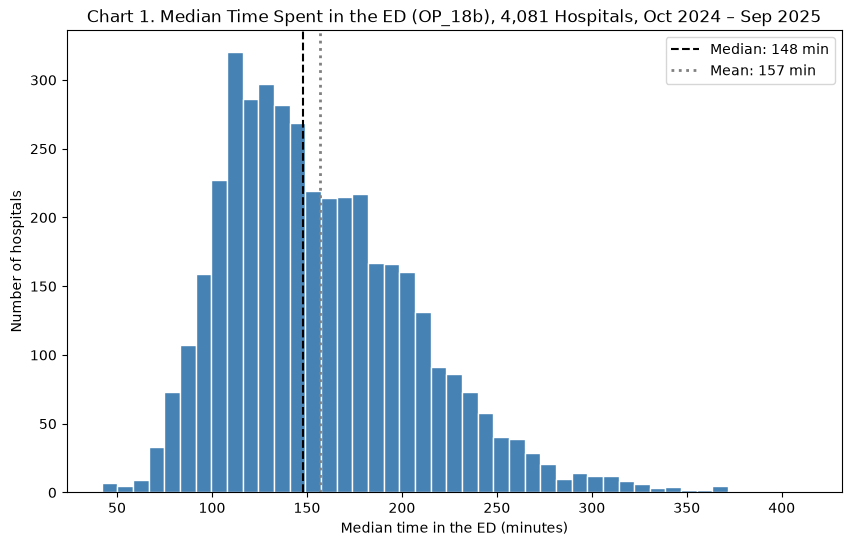

count   4,081.00
mean      156.94
std        50.84
min        42.00
25%       119.00
50%       148.00
75%       188.00
90%       225.00
max       413.00
Name: op_18b_min, dtype: float64

In [9]:
wait_minutes = waits_clean["op_18b_min"]
median_wait = wait_minutes.median()
mean_wait = wait_minutes.mean()

# Chart 1: distribution of the main outcome
plt.hist(wait_minutes, bins=45, color="steelblue", edgecolor="white")
plt.axvline(median_wait, color="black", linestyle="--", label=f"Median: {median_wait:.0f} min")
plt.axvline(mean_wait, color="gray", linestyle=":", linewidth=2, label=f"Mean: {mean_wait:.0f} min")

plt.title(f"Chart 1. Median Time Spent in the ED (OP_18b), {len(wait_minutes):,} Hospitals, Oct 2024 – Sep 2025")
plt.xlabel("Median time in the ED (minutes)")
plt.ylabel("Number of hospitals")
plt.legend()
plt.show()

wait_minutes.describe(percentiles=[0.25, 0.5, 0.75, 0.9])

**Answer Q1.2:** The typical hospital's median ED visit is **148 minutes** (about 2.5 hours). The middle half of hospitals falls between **119 and 188 minutes**, and one in ten hospitals exceeds **225 minutes**. The mean (157 minutes) is above the median because of a long right tail that reaches 413 minutes. *Caveat:* each value is a hospital-level median, so many individual patients wait considerably longer.

**Q1.3 Which states have the shortest and longest ED visits?**
For each state we take the median of its hospitals' `OP_18b` values. States with fewer than five reporting hospitals are excluded because a single hospital would dominate the result.

Excluded (fewer than 5 hospitals): ['GU']


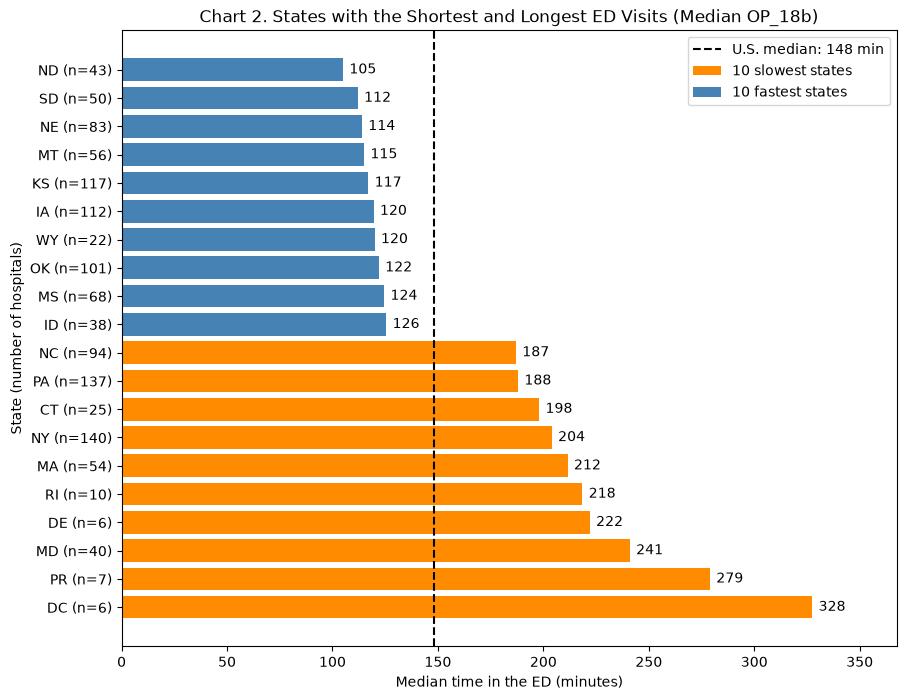

The slowest state is 3.1x the fastest


In [10]:
state_waits = waits_clean.groupby("state")["op_18b_min"].agg(["count", "median"])
state_waits.columns = ["hospitals", "median_minutes"]

print("Excluded (fewer than 5 hospitals):", list(state_waits[state_waits["hospitals"] < 5].index))
state_waits = state_waits[state_waits["hospitals"] >= 5]

# Sort from slowest to fastest and add the number of hospitals to each label
state_waits = state_waits.sort_values("median_minutes", ascending=False).reset_index()
state_waits["label"] = state_waits["state"] + " (n=" + state_waits["hospitals"].astype(str) + ")"

slowest = state_waits.head(10)
fastest = state_waits.tail(10)
national_median = waits_clean["op_18b_min"].median()

# Chart 2: horizontal bars, fastest states at the top and slowest at the bottom
plt.figure(figsize=(10, 8))
plt.barh(slowest["label"], slowest["median_minutes"], color="darkorange", label="10 slowest states")
plt.barh(fastest["label"], fastest["median_minutes"], color="steelblue", label="10 fastest states")
plt.axvline(national_median, color="black", linestyle="--", label=f"U.S. median: {national_median:.0f} min")

# Write the value at the end of each bar
shown = pd.concat([slowest, fastest])
for label, minutes in zip(shown["label"], shown["median_minutes"]):
    plt.text(minutes + 3, label, f"{minutes:.0f}", va="center")

plt.title("Chart 2. States with the Shortest and Longest ED Visits (Median OP_18b)")
plt.xlabel("Median time in the ED (minutes)")
plt.ylabel("State (number of hospitals)")
plt.xlim(0, slowest["median_minutes"].max() + 40)
plt.legend(loc="upper right")
plt.show()

print(f"The slowest state is {slowest['median_minutes'].max() / fastest['median_minutes'].min():.1f}x the fastest")

**Answer Q1.3:** **North Dakota is the fastest state at 105 minutes**, followed by South Dakota (112) and Nebraska (114). **The District of Columbia is the slowest at 328 minutes**, followed by Puerto Rico (279) and Maryland (241), a **3.1x gap** between the extremes. *Caveat:* DC, Delaware and Puerto Rico each have only 6–7 reporting hospitals, and dense urban areas may look slower partly because they have fewer small rural EDs.

**Q1.4 How much longer do psychiatric patients stay than other patients at the same hospital?**
We compare `OP_18c` (psychiatric patients) with `OP_18b` (other patients) for hospitals that report both.

In [11]:
psych = waits_clean.dropna(subset=["op_18c_min"]).copy()
psych["psych_gap_min"] = psych["op_18c_min"] - psych["op_18b_min"]

print("Hospitals reporting both measures:", len(psych))
print("Median gap (minutes):", psych["psych_gap_min"].median())
print(f"Mean gap (minutes): {psych['psych_gap_min'].mean():.1f}")
print(f"Hospitals where psychiatric patients stay longer: {(psych['psych_gap_min'] > 0).mean() * 100:.1f}%")

# The five hospitals with the largest gap
psych = psych.sort_values("psych_gap_min", ascending=False)
psych[["facility_name", "state", "op_18b_min", "op_18c_min", "psych_gap_min"]].head(5)

Hospitals reporting both measures: 3021
Median gap (minutes): 83.0
Mean gap (minutes): 109.5
Hospitals where psychiatric patients stay longer: 92.5%


,facility_name,state,op_18b_min,op_18c_min,psych_gap_min
3524,HCA HOUSTON HEALTHCARE KINGWOOD,TX,118.00,"1,196.00","1,078.00"
2642,CARTERET GENERAL HOSPITAL,NC,225.00,"1,212.00",987.00
2490,BASSETT HEALTHCARE,NY,199.00,"1,168.00",969.00
1681,JOHNS HOPKINS HOWARD COUNTY MEDICAL CENTER,MD,266.00,"1,166.00",900.00
2333,EXETER HOSPITAL INC,NH,206.00,"1,103.00",897.00


**Answer Q1.4:** Among the 3,021 hospitals that report both measures, psychiatric patients stay longer in **92.5%** of them. The **median gap is 83 minutes** and the mean is 110 minutes, so a small number of hospitals pull the average up. At the five most extreme hospitals, psychiatric patients stay roughly **15 to 18 hours longer** than other patients.

### 1.4 ED Crowding
The same CMS file also measures how busy each ED is. From `care_raw` we keep four more measures: `EDV` (ED volume), `OP_22` (% of patients who left before being seen), `OP_23` (% of stroke patients with a head CT result within 45 minutes) and `SEP_1` (% of sepsis patients who received the full recommended care). The cleaning steps are the same as for the wait times.

In [12]:
crowding_measures = ["EDV", "OP_22", "OP_23", "SEP_1"]
crowding_long = care_raw[care_raw["Measure ID"].isin(crowding_measures)].copy()

# Same fix as before: "Not Available" becomes a real missing value
crowding_long["Score"] = crowding_long["Score"].replace("Not Available", np.nan)

# Reporting period of each measure
print(crowding_long.groupby("Measure ID")[["Start Date", "End Date"]].first())
print()

# Missing values per measure
crowding_missing = crowding_long.groupby("Measure ID")["Score"].agg(["size", "count"])
crowding_missing["pct_missing"] = (crowding_missing["size"] - crowding_missing["count"]) / crowding_missing["size"] * 100
crowding_missing

            Start Date    End Date
Measure ID                        
EDV         01/01/2024  12/31/2024
OP_22       01/01/2024  12/31/2024
OP_23       10/01/2024  09/30/2025
SEP_1       10/01/2024  09/30/2025



,size,count,pct_missing
Measure ID,,,
EDV,4658,3826,17.86
OP_22,4658,3821,17.97
OP_23,4658,1492,67.97
SEP_1,4658,3115,33.13


`EDV` and `OP_22` cover calendar year 2024, while `OP_23` and `SEP_1` cover October 2024 to September 2025, the same period as the wait times. `OP_23` is missing for 68% of hospitals and measures stroke care rather than crowding, so it is dropped after reshaping. `EDV` is kept as text because it is a category, not a number.

In [13]:
crowding = crowding_long.pivot(index="Facility ID", columns="Measure ID", values="Score")
crowding = crowding.reset_index()
crowding.columns = ["facility_id", "edv_level", "op_22_left_pct", "op_23_ct_pct", "sep_1_pct"]

# The two percentage measures become numbers; OP_23 is dropped
crowding["op_22_left_pct"] = pd.to_numeric(crowding["op_22_left_pct"])
crowding["sep_1_pct"] = pd.to_numeric(crowding["sep_1_pct"])
crowding = crowding.drop(columns="op_23_ct_pct")

log_step("Section 1", "Score (EDV, OP_22, OP_23, SEP_1)", 'Missing values stored as the text "Not Available"',
         "Replaced with NaN", "Same treatment as the wait-time measures",
         crowding_long["Score"].isna().sum())
log_step("Section 1", "Crowding measures", "Long format: four rows per hospital",
         "Pivoted to one row per hospital", "Matches the wait-time table for merging",
         len(crowding_long) - len(crowding))
log_step("Section 1", "OP_23", "68% missing and measures stroke care, not crowding",
         "Dropped the column", "Keeps the crowding table focused", len(crowding))

print("Hospitals:", len(crowding))
crowding[["op_22_left_pct", "sep_1_pct"]].describe()

Hospitals: 4658


,op_22_left_pct,sep_1_pct
count,"3,821.00","3,115.00"
mean,1.69,63.79
std,1.76,16.10
min,0.00,0.00
25%,1.00,54.00
50%,1.00,65.00
75%,2.00,75.00
max,23.00,100.00


Both percentage measures stay within 0–100%. The highest `OP_22` value (23% of patients leaving before being seen) is extreme but possible, so it is kept.

**Q1.5 How many EDs are low, medium, high and very high volume?**

In [14]:
crowding["edv_level"].value_counts(dropna=False)

edv_level
low          1657
medium        914
NaN           832
very high     703
high          552
Name: count, dtype: int64

**Answer Q1.5:** Most EDs are small: **1,657 hospitals (35.6%) are low volume**, 914 (19.6%) medium, 552 (11.9%) high and **703 (15.1%) very high**. Volume is missing for 832 hospitals (17.9%). *Caveat:* volume is a CMS category, not an exact patient count.

**Q1.6 Do more patients leave before being seen at busier EDs?**

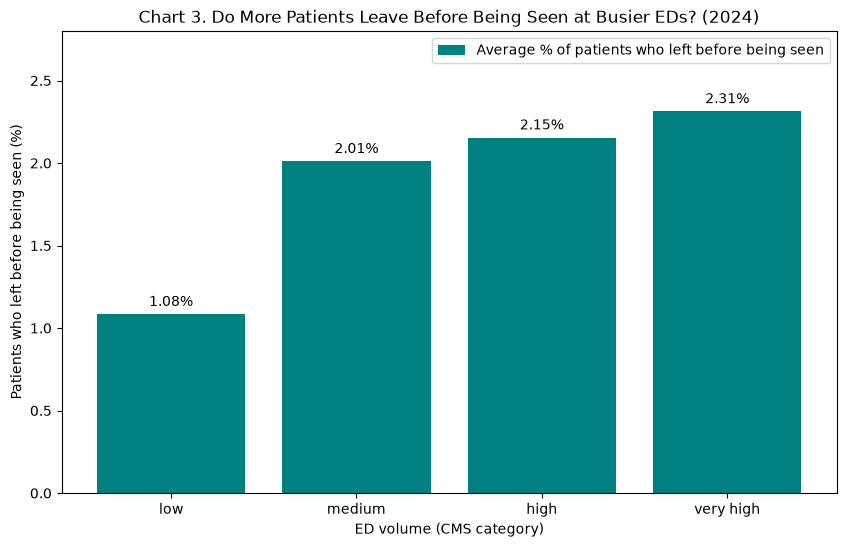

,count,mean,median
edv_level,,,
low,1652,1.08,1.00
medium,914,2.01,2.00
high,552,2.15,2.00
very high,703,2.31,2.00


In [15]:
volume_order = ["low", "medium", "high", "very high"]

left_by_volume = crowding.groupby("edv_level")["op_22_left_pct"].agg(["count", "mean", "median"])
left_by_volume = left_by_volume.reindex(volume_order)

# Chart 3: average % of patients who left before being seen, by ED volume
plt.bar(left_by_volume.index, left_by_volume["mean"], color="teal", label="Average % of patients who left before being seen")

# Write the value on top of each bar
for level, value in zip(left_by_volume.index, left_by_volume["mean"]):
    plt.text(level, value + 0.05, f"{value:.2f}%", ha="center")

plt.title("Chart 3. Do More Patients Leave Before Being Seen at Busier EDs? (2024)")
plt.xlabel("ED volume (CMS category)")
plt.ylabel("Patients who left before being seen (%)")
plt.ylim(0, 2.8)
plt.legend()
plt.show()

left_by_volume

**Answer Q1.6:** Yes. At low-volume EDs an average of **1.08%** of patients leave before being seen, compared with 2.01% at medium, 2.15% at high and **2.31% at very-high-volume EDs**, so the busiest EDs lose about twice as many patients. *Caveat:* these are averages of hospital percentages for 2024, and volume alone does not prove that crowding causes patients to leave.

**Q1.7 How consistently do hospitals follow the recommended sepsis care, and does it differ by ED volume?**

In [16]:
print(crowding["sep_1_pct"].describe())
print()
print("Median SEP_1 (%) by ED volume:")
print(crowding.groupby("edv_level")["sep_1_pct"].median().reindex(volume_order))

count   3,115.00
mean       63.79
std        16.10
min         0.00
25%        54.00
50%        65.00
75%        75.00
max       100.00
Name: sep_1_pct, dtype: float64

Median SEP_1 (%) by ED volume:
edv_level
low         67.00
medium      65.00
high        66.00
very high   64.00
Name: sep_1_pct, dtype: float64


**Answer Q1.7:** Across 3,115 reporting hospitals, the median hospital gives the full recommended sepsis care to **65%** of eligible patients, with a middle half between 54% and 75%. The rate barely changes with ED volume (67% at low-volume EDs vs. 64% at very-high-volume EDs), so busier EDs do not appear to follow sepsis guidelines less often. *Caveat:* `SEP_1` covers a different period (Oct 2024 – Sep 2025) than `EDV` (2024).

**Takeaway (Section 1):** Median ED visit times range from under an hour to almost seven hours depending on the hospital, and the fastest states are mostly rural Plains states. Busier EDs lose about twice as many patients before they are seen, which makes ED volume, location and hospital size the first factors to test once Sections 2 and 3 are merged. Psychiatric patients wait longer at almost every hospital, which is a clear operational issue for hospital leaders.

**Data dictionary: `waits_clean`**

| Column | Type | Description |
|---|---|---|
| `facility_id` | str | CMS hospital ID (merge key) |
| `facility_name` | str | Hospital name |
| `state` | str | Two-letter state code (merge key) |
| `op_18a_min` | float | Median ED minutes, all patients |
| `op_18b_min` | float | Median ED minutes, excluding psychiatric and transfer patients (main outcome) |
| `op_18c_min` | float | Median ED minutes, psychiatric / mental health patients |
| `op_18d_min` | float | Median ED minutes, patients transferred to another facility |

**Data dictionary: `crowding`**

| Column | Type | Description |
|---|---|---|
| `facility_id` | str | CMS hospital ID (merge key) |
| `edv_level` | str | ED volume: low, medium, high or very high (2024) |
| `op_22_left_pct` | float | % of patients who left before being seen (2024) |
| `sep_1_pct` | float | % of sepsis patients who received the full recommended care (Oct 2024 – Sep 2025) |

---
# Section 2: Hospital Characteristics
Dataset: CMS Hospital General Information · Chart 4

This section cleans the hospital profile table, which has one row per hospital: hospital type, ownership, CMS star rating and whether the hospital offers emergency services. The cleaned table is `hgi_cleaned` (merge key: `facility_id`).

**Questions**
- **Q2.1** What types of hospitals exist, and which of them offer emergency services?
- **Q2.2** Do star ratings differ between non-profit, for-profit and government hospitals? *(Chart 4)*
- **Q2.3** Which hospitals are missing a star rating, and is it random?
- **Q2.4** Which states rely most on Critical Access (small rural) hospitals?

### 2.1 Load and Inspect the Data

In [17]:
# The data was loaded in the Setup cell (Facility ID and ZIP Code as text so leading zeros are kept)
hgi.head()

,Facility ID,Facility Name,Address,City/Town,State,ZIP Code,County/Parish,Telephone Number,Hospital Type,Hospital Ownership,Emergency Services,Meets criteria for birthing friendly designation,Hospital overall rating,Hospital overall rating footnote,MORT Group Measure Count,Count of Facility MORT Measures,Count of MORT Measures Better,Count of MORT Measures No Different,Count of MORT Measures Worse,MORT Group Footnote,Safety Group Measure Count,Count of Facility Safety Measures,Count of Safety Measures Better,Count of Safety Measures No Different,Count of Safety Measures Worse,Safety Group Footnote,READM Group Measure Count,Count of Facility READM Measures,Count of READM Measures Better,Count of READM Measures No Different,Count of READM Measures Worse,READM Group Footnote,Pt Exp Group Measure Count,Count of Facility Pt Exp Measures,Pt Exp Group Footnote,TE Group Measure Count,Count of Facility TE Measures,TE Group Footnote
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,1108 ROSS CLARK CIRCLE,DOTHAN,AL,36301,HOUSTON,(334) 793-8701,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,4,NaN,8,8,0,8,0,NaN,8,7,3,4,0,NaN,11,11,1,9,1,NaN,15,15,NaN,10,10,NaN
1,010005,MARSHALL MEDICAL CENTERS,2505 U S HIGHWAY 431 NORTH,BOAZ,AL,35957,MARSHALL,(256) 593-8310,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,NaN,8,6,0,5,1,NaN,8,7,0,7,0,NaN,11,9,1,8,0,NaN,15,15,NaN,10,10,NaN
2,010006,NORTH ALABAMA MEDICAL CENTER,1701 VETERANS DRIVE,FLORENCE,AL,35630,LAUDERDALE,(256) 768-8400,Acute Care Hospitals,Proprietary,Yes,Y,2,NaN,8,8,0,5,3,NaN,8,8,4,4,0,NaN,11,9,1,8,0,NaN,15,15,NaN,10,9,NaN
3,010007,MIZELL MEMORIAL HOSPITAL,702 N MAIN ST,OPP,AL,36467,COVINGTON,(334) 493-3541,Acute Care Hospitals,Voluntary non-profit - Private,Yes,NaN,1,NaN,8,4,0,3,1,NaN,8,2,0,2,0,NaN,11,5,0,3,2,NaN,15,5,NaN,10,7,NaN
4,010011,ST. VINCENT'S EAST,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,AL,35235,JEFFERSON,(205) 838-3122,Acute Care Hospitals,Voluntary non-profit - Private,Yes,NaN,3,29,8,8,0,8,0,29.00,8,7,1,6,0,29.00,11,8,1,5,2,29.00,15,10,29.00,10,7,29.00


In [18]:
# Review data:
print(hgi.shape)
hgi.info()

(5419, 38)
<class 'pandas.DataFrame'>
RangeIndex: 5419 entries, 0 to 5418
Data columns (total 38 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       5419 non-null   str    
 1   Facility Name                                     5419 non-null   str    
 2   Address                                           5419 non-null   str    
 3   City/Town                                         5419 non-null   str    
 4   State                                             5419 non-null   str    
 5   ZIP Code                                          5419 non-null   str    
 6   County/Parish                                     5419 non-null   str    
 7   Telephone Number                                  5419 non-null   str    
 8   Hospital Type                                     5419 non-null   str    
 9   Hospital Ownership 

In [19]:
# Checking if any duplicate facility IDs exist
hgi['Facility ID'].duplicated().value_counts() # No duplicate facility IDs

Facility ID
False    5419
Name: count, dtype: int64

Missing values in this file are hidden: many cells contain the text `"Not Available"`, which `isna()` does not count. The table below counts both real `NaN` values and `"Not Available"` text in each column.

In [20]:
## Count number of NaN cells and 'Not Available' values in each column
column_na_counts = pd.DataFrame({
    'NaN': hgi.isnull().sum(),
    'Not Available': (hgi == 'Not Available').sum()
})

column_na_counts['% missing total'] = round((((column_na_counts['NaN'] + column_na_counts['Not Available']) / hgi.shape[0]) * 100),2)

# Only show the columns that have missing values
column_na_counts[column_na_counts['% missing total'] > 0]

,NaN,Not Available,% missing total
Meets criteria for birthing friendly designation,3156,0,58.24
Hospital overall rating,0,2245,41.43
Hospital overall rating footnote,3103,0,57.26
MORT Group Measure Count,0,850,15.69
Count of Facility MORT Measures,0,1323,24.41
Count of MORT Measures Better,0,1323,24.41
Count of MORT Measures No Different,0,1323,24.41
Count of MORT Measures Worse,0,1323,24.41
MORT Group Footnote,4023,0,74.24
Safety Group Measure Count,0,850,15.69


In [21]:
# Replace 'Not Available' with np.nan everywhere:
hgi.replace('Not Available', np.nan, inplace = True)

# Check if cells were successfully replaced
print('"Not Available" cells left:', (hgi == "Not Available").sum().sum())

"Not Available" cells left: 0


### 2.2 Clean and Simplify

In [22]:
## Fixing data types

# Changing Hospital overall rating column to Int64 (whole numbers that allow NaN):
hgi['Hospital overall rating'] = pd.to_numeric(hgi['Hospital overall rating']).astype('Int64')

# Making a list of column names containing the word: 'count'
numeric_cols = [col for col in hgi.columns if 'count' in col.lower()]
numeric_cols.remove('County/Parish')

# converting list of numeric_cols to numeric data type
hgi[numeric_cols] = hgi[numeric_cols].apply(pd.to_numeric)

print("Columns converted to numbers:", len(numeric_cols) + 1)

Columns converted to numbers: 20


In [23]:
## Creating a new column 'Has_ER' that is True/False if the hospital has emergency services
hgi['Has_ER'] = hgi['Emergency Services'].map({'Yes': True, 'No' : False})
hgi['Has_ER'].value_counts()

Has_ER
True     4495
False     924
Name: count, dtype: int64

In [24]:
# Before dropping the footnotes: the rating footnote explains why a rating is missing (used in Q2.3)
hgi['Hospital overall rating footnote'].value_counts()

Hospital overall rating footnote
16        1337
19         801
5           71
29          60
22          32
23          11
16, 23       3
11           1
Name: count, dtype: int64

In [25]:
# Birthing friendly column: NaN here just means "not designated". Fill with "N", make it True/False.
hgi['Meets criteria for birthing friendly designation'] = hgi['Meets criteria for birthing friendly designation'].replace(np.nan, 'N')
hgi['Birthing Friendly'] = hgi['Meets criteria for birthing friendly designation'].map({'Y': True, 'N' : False})
hgi['Birthing Friendly'].value_counts()

Birthing Friendly
False    3156
True     2263
Name: count, dtype: int64

In [26]:
# drop footnote columns and the telephone number column
footnote_cols = [col for col in hgi.columns if 'footnote' in col.lower()]

# new df: hgi_cleaned with dropped columns
hgi_cleaned = hgi.drop(columns = footnote_cols + ['Telephone Number'])
print("Columns dropped:", footnote_cols + ['Telephone Number'])

Columns dropped: ['Hospital overall rating footnote', 'MORT Group Footnote', 'Safety Group Footnote', 'READM Group Footnote', 'Pt Exp Group Footnote', 'TE Group Footnote', 'Telephone Number']


In [27]:
## Simplify the 12 ownership labels into 5 groups
owner_dict = {'Voluntary non-profit - Private': 'Non profit', 'Voluntary non-profit - Other' : 'Non profit',
              'Voluntary non-profit - Church' : 'Non profit', 'Proprietary' : 'For profit', 'Physician': 'For profit',
              'Government - State':'Government', 'Government - Local':'Government',
              'Government - Hospital District or Authority':'Government', 'Veterans Health Administration':'Federal',
              'Department of Defense' : 'Federal','Government - Federal' : 'Federal', 'Tribal':'Tribal'}
hgi_cleaned['Ownership Group'] = hgi_cleaned['Hospital Ownership'].map(owner_dict)
hgi_cleaned['Ownership Group'].value_counts()

Ownership Group
Non profit    2939
For profit    1143
Government    1114
Federal        206
Tribal          17
Name: count, dtype: int64

In [28]:
# Flag is_territory for PR, GU, VI, AS, MP (they may not show up in the Census file).
territories = ['PR', 'GU', 'VI', 'AS', 'MP']
hgi_cleaned['is_territory'] = hgi_cleaned['State'].isin(territories)
hgi_cleaned['is_territory'].value_counts()

is_territory
False    5354
True       65
Name: count, dtype: int64

In [29]:
# After cleaning: correct data types, footnote columns removed, new grouping columns added
hgi_cleaned.info()

<class 'pandas.DataFrame'>
RangeIndex: 5419 entries, 0 to 5418
Data columns (total 35 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   Facility ID                                       5419 non-null   str    
 1   Facility Name                                     5419 non-null   str    
 2   Address                                           5419 non-null   str    
 3   City/Town                                         5419 non-null   str    
 4   State                                             5419 non-null   str    
 5   ZIP Code                                          5419 non-null   str    
 6   County/Parish                                     5419 non-null   str    
 7   Hospital Type                                     5419 non-null   str    
 8   Hospital Ownership                                5419 non-null   str    
 9   Emergency Services            

### 2.3 Explore
**Q2.1 What types of hospitals exist, and which of them offer emergency services?**

In [30]:
er_hospital_table = pd.crosstab(hgi_cleaned['Hospital Type'], hgi_cleaned['Has_ER'], margins=True)
er_hospital_table['% with ER'] = round(((er_hospital_table[True] / er_hospital_table['All']) * 100),2)

er_hospital_table

Has_ER,False,True,All,% with ER
Hospital Type,,,,
Acute Care - Department of Defense,1,31,32,96.88
Acute Care - Veterans Administration,20,112,132,84.85
Acute Care Hospitals,282,2825,3107,90.92
Childrens,39,55,94,58.51
Critical Access Hospitals,39,1343,1382,97.18
Long-term,5,0,5,0.00
Psychiatric,538,86,624,13.78
Rural Emergency Hospital,0,43,43,100.00
All,924,4495,5419,82.95


**Answer Q2.1:** Of the 5,419 hospitals, **4,495 (83.0%) offer emergency services** and 924 do not. Almost all Critical Access (97.2%) and acute care hospitals (90.9%) have an ED, but only **13.8% of psychiatric hospitals** and 58.5% of children's hospitals do. *Caveat:* 161 hospitals that report ED wait times in Section 1 are listed here as having no emergency services, which should be reviewed in the final analysis.

**Q2.2 Do star ratings differ between non-profit, for-profit and government hospitals?**

In [31]:
## Subsetting hospitals that have a rating
hgi_rating = hgi_cleaned[hgi_cleaned['Hospital overall rating'].notna()]
## Contingency table showing ownership group and overall rating
table_rating_by_group = pd.crosstab(hgi_rating['Ownership Group'], hgi_rating['Hospital overall rating'], normalize='index')* 100
table_rating_by_group

Hospital overall rating,1,2,3,4,5
Ownership Group,,,,,
Federal,0.00,9.76,17.07,32.52,40.65
For profit,9.81,32.69,28.85,22.88,5.77
Government,9.89,26.74,32.36,24.04,6.97
Non profit,4.94,17.28,32.12,32.65,13.01
Tribal,0.00,0.00,33.33,0.00,66.67


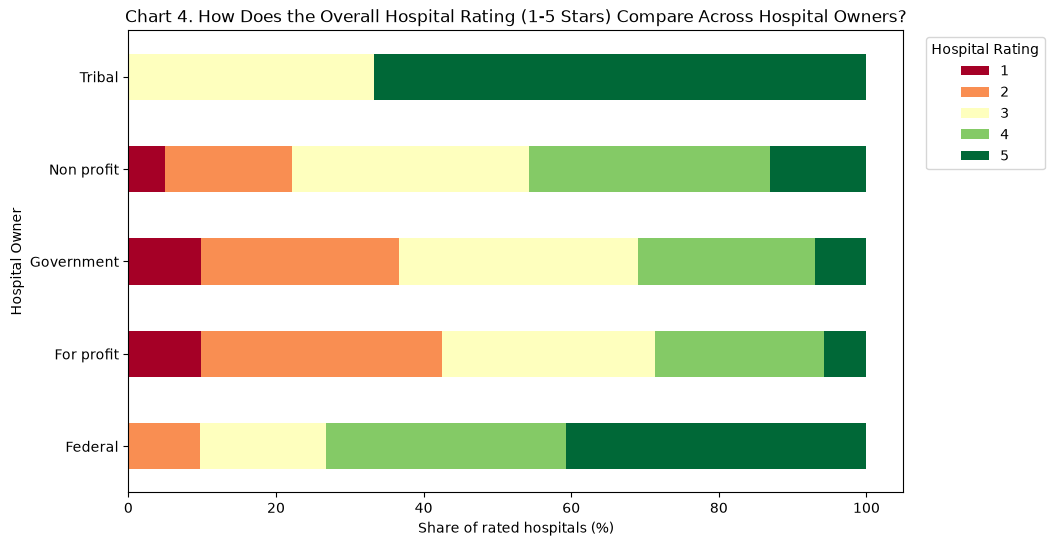

In [32]:
# Chart 3: share of each star rating within each ownership group
ax = table_rating_by_group.plot(kind = 'barh', stacked=True, colormap='RdYlGn')
ax.set_title('Chart 4. How Does the Overall Hospital Rating (1-5 Stars) Compare Across Hospital Owners?')
ax.set_xlabel('Share of rated hospitals (%)')
ax.set_ylabel('Hospital Owner')
ax.legend(title = 'Hospital Rating', bbox_to_anchor=(1.02,1), loc='upper left')
plt.show()

In [33]:
# Table of average star rating and number of rated hospitals per group
hgi_rating.groupby('Ownership Group')['Hospital overall rating'].agg(['mean', 'count'])

,mean,count
Ownership Group,,
Federal,4.04,123
For profit,2.82,520
Government,2.91,445
Non profit,3.31,2083
Tribal,4.33,3


**Answer Q2.2:** Yes. Among rated hospitals, **45.7% of non-profit hospitals have 4 or 5 stars** (average 3.31), compared with **28.7% of for-profit hospitals** (average 2.82) and 31.0% of government hospitals (average 2.91). For-profit hospitals also have the largest share of 1–2 star ratings (42.5%). Federal hospitals score highest (average 4.04, 123 rated hospitals), while the Tribal group has only 3 rated hospitals, so its result is not meaningful. *Caveat:* the star rating combines many quality measures and is not an ED-specific score.

**Q2.3 Which hospitals are missing a star rating, and is it random?**

In [34]:
## Adding a rating_missing flag
hgi_cleaned['Rating_missing'] = hgi_cleaned['Hospital overall rating'].isnull()

## Number of missing ratings by hospital type, sorted high to low
missing_rating_by_hospital_type = hgi_cleaned.groupby('Hospital Type')['Rating_missing'].sum().reset_index()
missing_rating_by_hospital_type['% of Missing Rating'] = round(((missing_rating_by_hospital_type['Rating_missing'] /missing_rating_by_hospital_type['Rating_missing'].sum() ) * 100),2)
missing_rating_by_hospital_type = missing_rating_by_hospital_type.sort_values(by='% of Missing Rating', ascending = False)
missing_rating_by_hospital_type

,Hospital Type,Rating_missing,% of Missing Rating
4,Critical Access Hospitals,983,43.79
6,Psychiatric,624,27.80
2,Acute Care Hospitals,444,19.78
3,Childrens,94,4.19
7,Rural Emergency Hospital,43,1.92
0,Acute Care - Department of Defense,32,1.43
1,Acute Care - Veterans Administration,20,0.89
5,Long-term,5,0.22


**Answer Q2.3:** No, missing ratings are not random. **2,245 hospitals (41.4%) have no star rating**, and most of them are Critical Access hospitals (43.8% of the missing ratings) or psychiatric hospitals (27.8%). Every psychiatric and children's hospital is unrated, as are 983 of the 1,382 Critical Access hospitals (71%). The rating footnotes show why: the most common codes are 16 (too few measures reported to calculate a rating) and 19 (hospital not in the CMS programs that produce ratings). We therefore leave these ratings missing rather than filling them in.

**Q2.4 Which states rely most on Critical Access hospitals?** Only states with at least 10 hospitals are included.

In [35]:
hgi_cleaned['is_critical_access'] = hgi_cleaned['Hospital Type'] == 'Critical Access Hospitals'

critical_access_table = hgi_cleaned.groupby('State')['is_critical_access'].agg(
    total_hospitals='size', number_critical_access='sum', percent_critical_access='mean'
)
critical_access_table['percent_critical_access'] = (critical_access_table['percent_critical_access'] * 100).round(2)

critical_access_table.rename(columns = {'total_hospitals':'Total Hospitals', 'number_critical_access' : '# Critical Access',
                              'percent_critical_access' : '% Critical Access'}, inplace=True)
critical_access_table.head()

,Total Hospitals,# Critical Access,% Critical Access
State,,,
AK,25,13,52.00
AL,99,9,9.09
AR,90,29,32.22
AS,1,0,0.00
AZ,108,17,15.74


In [36]:
critical_access_table = critical_access_table[critical_access_table["Total Hospitals"] >= 10].sort_values(by='% Critical Access', ascending = False)
print("Top 10 States by % Critical Access (10+ Hospitals)")
print(critical_access_table.head(10))
print()
print("Bottom 5 States by % Critical Access (10+ Hospitals)")
print(critical_access_table.tail(5))

Top 10 States by % Critical Access (10+ Hospitals)
       Total Hospitals  # Critical Access  % Critical Access
State                                                       
MT                  63                 50              79.37
ND                  47                 37              78.72
IA                 118                 82              69.49
NE                  93                 62              66.67
SD                  61                 39              63.93
WY                  31                 19              61.29
KS                 139                 83              59.71
MN                 136                 76              55.88
ID                  48                 26              54.17
AK                  25                 13              52.00

Bottom 5 States by % Critical Access (10+ Hospitals)
       Total Hospitals  # Critical Access  % Critical Access
State                                                       
RI                  13                  0

**Answer Q2.4:** Rural Plains and Mountain states rely most on Critical Access hospitals: **Montana (79.4%)**, North Dakota (78.7%), Iowa (69.5%), Nebraska (66.7%) and South Dakota (63.9%). Connecticut, Delaware, Maryland, Rhode Island and DC have none. These are largely the same states that had the fastest and slowest ED visits in Chart 2, which makes rurality a key factor to test after the merge.

### 2.4 Final Checks

In [37]:
print("Not Available" in hgi_cleaned['Facility ID'].unique())
print(hgi_cleaned.shape[0] == len(hgi_cleaned['Facility ID'].unique()))

# rename all columns to snake case
hgi_cleaned.columns = hgi_cleaned.columns.str.strip().str.lower().str.replace(' ', '_').str.replace('/', '_')
print(hgi_cleaned.columns.tolist())

False
True
['facility_id', 'facility_name', 'address', 'city_town', 'state', 'zip_code', 'county_parish', 'hospital_type', 'hospital_ownership', 'emergency_services', 'meets_criteria_for_birthing_friendly_designation', 'hospital_overall_rating', 'mort_group_measure_count', 'count_of_facility_mort_measures', 'count_of_mort_measures_better', 'count_of_mort_measures_no_different', 'count_of_mort_measures_worse', 'safety_group_measure_count', 'count_of_facility_safety_measures', 'count_of_safety_measures_better', 'count_of_safety_measures_no_different', 'count_of_safety_measures_worse', 'readm_group_measure_count', 'count_of_facility_readm_measures', 'count_of_readm_measures_better', 'count_of_readm_measures_no_different', 'count_of_readm_measures_worse', 'pt_exp_group_measure_count', 'count_of_facility_pt_exp_measures', 'te_group_measure_count', 'count_of_facility_te_measures', 'has_er', 'birthing_friendly', 'ownership_group', 'is_territory', 'rating_missing', 'is_critical_access']


**Cleaning log (Section 2)**

In [38]:
log_step("Section 2", "All columns", 'Missing values stored as the text "Not Available"',
         "Replaced with NaN", "Lets pandas count and handle missing values correctly",
         column_na_counts['Not Available'].sum())
log_step("Section 2", "Hospital overall rating, count columns", "Numbers stored as text",
         "Converted to numbers (rating as Int64)", "Allows averages and comparisons", len(hgi))
log_step("Section 2", "Emergency Services, birthing friendly", "Yes/No and Y/blank text",
         "Converted to True/False (blank = not designated)", "Easier to count and filter", len(hgi))
log_step("Section 2", "6 footnote columns, Telephone Number", "Not needed for the analysis",
         "Dropped 7 columns", "Footnotes were reviewed first (Q2.3)", 0)
log_step("Section 2", "Hospital Ownership", "12 detailed ownership labels",
         "Grouped into 5 ownership groups", "Makes group comparisons readable", len(hgi))
log_step("Section 2", "All columns", "Column names with spaces and capitals",
         "Renamed to snake_case", "Consistent names for merging", 0)

section2_log = pd.DataFrame(cleaning_log)
section2_log[section2_log["Dataset"] == "Section 2"]

,Dataset,Column,Issue,Action,Why,Rows affected
8,Section 2,All columns,"Missing values stored as the text ""Not Available""",Replaced with NaN,Lets pandas count and handle missing values correctly,27581
9,Section 2,"Hospital overall rating, count columns",Numbers stored as text,Converted to numbers (rating as Int64),Allows averages and comparisons,5419
10,Section 2,"Emergency Services, birthing friendly",Yes/No and Y/blank text,Converted to True/False (blank = not designated),Easier to count and filter,5419
11,Section 2,"6 footnote columns, Telephone Number",Not needed for the analysis,Dropped 7 columns,Footnotes were reviewed first (Q2.3),0
12,Section 2,Hospital Ownership,12 detailed ownership labels,Grouped into 5 ownership groups,Makes group comparisons readable,5419
13,Section 2,All columns,Column names with spaces and capitals,Renamed to snake_case,Consistent names for merging,0


**Takeaway (Section 2):** The hospital table needed data type fixes and the replacement of 27,581 hidden "Not Available" values, but no hospitals had to be removed. Non-profit and federal hospitals receive higher star ratings than for-profit and government hospitals, and the states with many small rural hospitals are the same states with the fastest EDs. Ownership, hospital type and rurality are therefore key variables for the merged analysis.

**Data dictionary: `hgi_cleaned` (key columns)**

| Column | Type | Description |
|---|---|---|
| `facility_id` | str | CMS hospital ID (merge key) |
| `state` | str | Two-letter state code |
| `hospital_type` | str | CMS hospital type (e.g. Acute Care, Critical Access, Psychiatric) |
| `ownership_group` | str | Simplified owner: Non profit, For profit, Government, Federal, Tribal |
| `hospital_overall_rating` | Int64 | CMS star rating 1–5, NaN if not rated |
| `has_er` | bool | Hospital offers emergency services |
| `birthing_friendly` | bool | Meets the CMS birthing-friendly criteria |
| `is_territory` | bool | Located in PR, GU, VI, AS or MP |
| `is_critical_access` | bool | Critical Access (small rural) hospital |
| `rating_missing` | bool | No star rating available |

---
# Section 3: State Economic Conditions
Dataset: U.S. Census ACS 2024 1-Year, Table DP03 (all states) · Chart 5

This section prepares state-level economic indicators (income, employment, poverty and health insurance) so they can be joined to each hospital by state. The cleaned table is `final_acs_dataset` (merge key: `state`).

**Questions**
- **Q3.1** Which states have the highest and lowest share of people without health insurance?
- **Q3.2** How do income and uninsured rates relate across states? *(Chart 5)*
- **Q3.3** Which states are furthest above or below the U.S. average on income and poverty?
- **Q3.4** Which states rely most on public health coverage, and which have the longest commutes?

### 3.1 Load and Inspect the Data

In [39]:
print(acs.shape)
print("Duplicate states:", acs["NAME"].duplicated().sum())
print("Missing values:", acs.isna().sum().sum())
acs.head()

(52, 25)
Duplicate states: 0
Missing values: 0


,GEO_ID,NAME,DP03_0002PE,DP03_0009PE,DP03_0021PE,DP03_0024PE,DP03_0025E,DP03_0042PE,DP03_0062E,DP03_0062M,DP03_0063E,DP03_0088E,DP03_0092E,DP03_0066PE,DP03_0074PE,DP03_0096PE,DP03_0097PE,DP03_0098PE,DP03_0099PE,DP03_0099PM,DP03_0101PE,DP03_0119PE,DP03_0128PE,DP03_0129PE,DP03_0135PE
0,0400000US01,Alabama,59.20,4.20,0.40,8.30,26.00,22.90,66659,780,90741,36940,41871,34.80,13.10,91.80,67.50,37.90,8.20,0.30,4.30,10.90,15.20,20.20,13.00
1,0400000US02,Alaska,66.60,6.00,0.70,8.40,19.80,26.30,95665,3278,122082,47267,50872,26.50,10.40,89.00,65.80,37.80,11.00,0.80,8.80,6.50,10.20,13.00,8.40
2,0400000US04,Arizona,61.40,4.60,1.10,16.30,26.40,22.30,81486,684,110522,43676,46251,34.20,10.20,89.70,65.00,37.60,10.30,0.40,9.30,7.90,11.70,14.60,10.50
3,0400000US05,Arkansas,59.00,3.80,0.30,8.60,22.70,24.10,62106,831,85474,34812,40734,34.80,9.00,90.60,60.80,42.60,9.40,0.50,7.70,11.30,15.50,20.00,12.20
4,0400000US06,California,64.20,5.90,3.30,14.10,29.70,22.90,100149,381,140112,49934,50460,28.80,13.50,94.10,63.20,41.00,5.90,0.10,3.10,8.50,11.80,14.60,11.80


In [40]:
# Before cleaning: column names are Census codes
acs.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 25 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   GEO_ID       52 non-null     str    
 1   NAME         52 non-null     str    
 2   DP03_0002PE  52 non-null     float64
 3   DP03_0009PE  52 non-null     float64
 4   DP03_0021PE  52 non-null     float64
 5   DP03_0024PE  52 non-null     float64
 6   DP03_0025E   52 non-null     float64
 7   DP03_0042PE  52 non-null     float64
 8   DP03_0062E   52 non-null     int64  
 9   DP03_0062M   52 non-null     int64  
 10  DP03_0063E   52 non-null     int64  
 11  DP03_0088E   52 non-null     int64  
 12  DP03_0092E   52 non-null     int64  
 13  DP03_0066PE  52 non-null     float64
 14  DP03_0074PE  52 non-null     float64
 15  DP03_0096PE  52 non-null     float64
 16  DP03_0097PE  52 non-null     float64
 17  DP03_0098PE  52 non-null     float64
 18  DP03_0099PE  52 non-null     float64
 19  DP03_0099PM  52 non-n

### 3.2 Clean the Data
Column names are Census codes (`E` = estimate, `PE` = percent, `M` / `PM` = margin of error). We rename them using the DP03 codebook.

In [41]:
# Census code -> readable name (from the Census DP03 codebook)
census_names = {
    "GEO_ID": "geo_id",
    "NAME": "state_name",
    "DP03_0002PE": "labor_force_pct",
    "DP03_0009PE": "unemployment_pct",
    "DP03_0021PE": "public_transit_pct",
    "DP03_0024PE": "work_from_home_pct",
    "DP03_0025E": "commute_min",
    "DP03_0042PE": "edu_health_jobs_pct",
    "DP03_0062E": "median_hh_income",
    "DP03_0062M": "median_hh_income_moe",
    "DP03_0063E": "mean_hh_income",
    "DP03_0088E": "per_capita_income",
    "DP03_0092E": "median_worker_earnings",
    "DP03_0066PE": "social_security_pct",
    "DP03_0074PE": "snap_pct",
    "DP03_0096PE": "insured_pct",
    "DP03_0097PE": "private_insurance_pct",
    "DP03_0098PE": "public_insurance_pct",
    "DP03_0099PE": "uninsured_pct",
    "DP03_0099PM": "uninsured_pct_moe",
    "DP03_0101PE": "uninsured_kids_pct",
    "DP03_0119PE": "family_poverty_pct",
    "DP03_0128PE": "poverty_pct",
    "DP03_0129PE": "child_poverty_pct",
    "DP03_0135PE": "senior_poverty_pct",
}

acs = acs.rename(columns=census_names)
print(acs.columns.tolist())

['geo_id', 'state_name', 'labor_force_pct', 'unemployment_pct', 'public_transit_pct', 'work_from_home_pct', 'commute_min', 'edu_health_jobs_pct', 'median_hh_income', 'median_hh_income_moe', 'mean_hh_income', 'per_capita_income', 'median_worker_earnings', 'social_security_pct', 'snap_pct', 'insured_pct', 'private_insurance_pct', 'public_insurance_pct', 'uninsured_pct', 'uninsured_pct_moe', 'uninsured_kids_pct', 'family_poverty_pct', 'poverty_pct', 'child_poverty_pct', 'senior_poverty_pct']


In [42]:
#Chat helped me with simplifying writing all this down:
State_Letters = {
    "Alabama": "AL",
    "Alaska": "AK",
    "Arizona": "AZ",
    "Arkansas": "AR",
    "California": "CA",
    "Colorado": "CO",
    "Connecticut": "CT",
    "Delaware": "DE",
    "District of Columbia": "DC",
    "Florida": "FL",
    "Georgia": "GA",
    "Hawaii": "HI",
    "Idaho": "ID",
    "Illinois": "IL",
    "Indiana": "IN",
    "Iowa": "IA",
    "Kansas": "KS",
    "Kentucky": "KY",
    "Louisiana": "LA",
    "Maine": "ME",
    "Maryland": "MD",
    "Massachusetts": "MA",
    "Michigan": "MI",
    "Minnesota": "MN",
    "Mississippi": "MS",
    "Missouri": "MO",
    "Montana": "MT",
    "Nebraska": "NE",
    "Nevada": "NV",
    "New Hampshire": "NH",
    "New Jersey": "NJ",
    "New Mexico": "NM",
    "New York": "NY",
    "North Carolina": "NC",
    "North Dakota": "ND",
    "Ohio": "OH",
    "Oklahoma": "OK",
    "Oregon": "OR",
    "Pennsylvania": "PA",
    "Rhode Island": "RI",
    "South Carolina": "SC",
    "South Dakota": "SD",
    "Tennessee": "TN",
    "Texas": "TX",
    "Utah": "UT",
    "Vermont": "VT",
    "Virginia": "VA",
    "Washington": "WA",
    "West Virginia": "WV",
    "Wisconsin": "WI",
    "Wyoming": "WY",
    "Puerto Rico": "PR"
}

#creates new column state
acs["state"] = acs["state_name"].map(State_Letters)

#Check that every row has received a unique state code (CA, MA):

if acs["state"].notna().all():
    print("All rows have a state code")
else:
    print("Some rows are missing a state code")

if acs["state"].is_unique:
    print("All state codes are unique")
else:
    print("There are duplicate state codes in this data")

print("The number of unique state codes are:", acs["state"].nunique())

All rows have a state code
All state codes are unique
The number of unique state codes are: 52


Next we check that the numbers make sense: percentages must be between 0 and 100, money values cannot be negative, and insured plus uninsured should add up to 100%.

In [43]:
#Check percentage columns:

percentage_out_of_range = 0

for x in acs.columns:
    if x.endswith("_pct"):
        for number in acs[x]:
            if number < 0 or number > 100:
                percentage_out_of_range += 1
print("The number of percentage values outside the range of 0-100 is:", percentage_out_of_range)

#Check money columns:

money_x = ["median_hh_income", "median_hh_income_moe", "mean_hh_income", "per_capita_income", "median_worker_earnings"]

negative_money = 0

for x in money_x:
    for number in acs[x]:
        if number < 0:
            negative_money += 1
print("The number of negative money values is:", negative_money)

#Insured + not insured check:

v_difference = 0

for i in range(len(acs)):
    total_insurance = acs.loc[i, "insured_pct"] + acs.loc[i, "uninsured_pct"]
    difference = abs(100 - total_insurance)

    if difference > v_difference:
        v_difference = difference

print("The largest difference from 100 between insured % + uninsured % is:", round(v_difference, 2))

The number of percentage values outside the range of 0-100 is: 0
The number of negative money values is: 0
The largest difference from 100 between insured % + uninsured % is: 0


The Census reports a margin of error for each estimate. We use it to check how reliable the state-level numbers are.

In [44]:
#Creating High and Low Ranges using the margin of error:

acs["uninsured_pct_low"] = (acs["uninsured_pct"] - acs["uninsured_pct_moe"])
acs["uninsured_pct_high"] = (acs["uninsured_pct"] + acs["uninsured_pct_moe"])
acs["median_hh_income_low"] = (acs["median_hh_income"] - acs["median_hh_income_moe"])
acs["median_hh_income_high"] = (acs["median_hh_income"] + acs["median_hh_income_moe"])

#Relative Error for median household income

acs["income_relative_to_error_pct"] = (acs["median_hh_income_moe"] / acs["median_hh_income"]) * 100

#Showing the top 5 states with the biggest relative error

top_5_biggest_error = acs[["state_name", "median_hh_income", "median_hh_income_moe", "median_hh_income_low", "median_hh_income_high", "income_relative_to_error_pct", "uninsured_pct_low", "uninsured_pct_high"]]

top_5_biggest_error = top_5_biggest_error.sort_values("income_relative_to_error_pct", ascending = False)

top_5_error = top_5_biggest_error.head(5)

print("The top 5 states with the biggest relative error are:")
top_5_error

The top 5 states with the biggest relative error are:


,state_name,median_hh_income,median_hh_income_moe,median_hh_income_low,median_hh_income_high,income_relative_to_error_pct,uninsured_pct_low,uninsured_pct_high
39,Rhode Island,83504,3548,79956,87052,4.25,4.00,5.20
8,District of Columbia,109707,4149,105558,113856,3.78,3.80,5.20
34,North Dakota,77871,2755,75116,80626,3.54,5.40,6.80
1,Alaska,95665,3278,92387,98943,3.43,10.20,11.80
50,Wyoming,75532,2468,73064,78000,3.27,9.30,11.30


Puerto Rico is very different from every state. Our CMS data includes Puerto Rico hospitals, so we keep it in the clean file but flag it, and leave it out of Chart 5 so it does not stretch the chart.

In [45]:
# Puerto Rico compared with the median of the 50 states + DC
puerto_rico = acs[acs["state"] == "PR"]
states_only = acs[acs["state"] != "PR"]

print("Puerto Rico median household income:", puerto_rico["median_hh_income"].values[0])
print("Median state household income:", states_only["median_hh_income"].median())
print("Puerto Rico poverty rate (%):", puerto_rico["poverty_pct"].values[0])
print("Median state poverty rate (%):", states_only["poverty_pct"].median())

# Keep Puerto Rico but flag it as a territory
acs["is_territory"] = acs["state"] == "PR"

Puerto Rico median household income: 27213
Median state household income: 77871.0
Puerto Rico poverty rate (%): 37.3
Median state poverty rate (%): 11.6


Finally we add the U.S. values from the national DP03 table and compare each state against them.

In [46]:
United_States_values = {"median_hh_income": 81604, "unemployment_pct": 4.6, "uninsured_pct": 8.2, "poverty_pct": 12.1}

#Creating columns comparing each state relative to the US values:

acs["state_income_vs_us"] = acs["median_hh_income"] - United_States_values["median_hh_income"]

acs["state_unemployment_vs_us"] = acs["unemployment_pct"] - United_States_values["unemployment_pct"]

acs["state_uninsured_vs_us"] = acs["uninsured_pct"] - United_States_values["uninsured_pct"]

acs["state_poverty_vs_us"] = acs["poverty_pct"] - United_States_values["poverty_pct"]

#Chat Helped Copying This Code More Efficient than Typing Out#
final_dataset_column_names = [
    "state_name",
    "state",
    "is_territory",
    "labor_force_pct",
    "unemployment_pct",
    "public_transit_pct",
    "work_from_home_pct",
    "commute_min",
    "edu_health_jobs_pct",
    "median_hh_income",
    "median_hh_income_moe",
    "median_hh_income_low",
    "median_hh_income_high",
    "mean_hh_income",
    "social_security_pct",
    "snap_pct",
    "per_capita_income",
    "median_worker_earnings",
    "insured_pct",
    "private_insurance_pct",
    "public_insurance_pct",
    "uninsured_pct",
    "uninsured_pct_moe",
    "uninsured_pct_low",
    "uninsured_pct_high",
    "family_poverty_pct",
    "poverty_pct",
    "child_poverty_pct",
    "senior_poverty_pct",
    "income_relative_to_error_pct",
    "state_income_vs_us",
    "state_unemployment_vs_us",
    "state_uninsured_vs_us",
    "state_poverty_vs_us"
]

final_acs_dataset = acs[final_dataset_column_names]

# After cleaning: readable names, state code and comparison columns added
final_acs_dataset.info()

<class 'pandas.DataFrame'>
RangeIndex: 52 entries, 0 to 51
Data columns (total 34 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   state_name                    52 non-null     str    
 1   state                         52 non-null     str    
 2   is_territory                  52 non-null     bool   
 3   labor_force_pct               52 non-null     float64
 4   unemployment_pct              52 non-null     float64
 5   public_transit_pct            52 non-null     float64
 6   work_from_home_pct            52 non-null     float64
 7   commute_min                   52 non-null     float64
 8   edu_health_jobs_pct           52 non-null     float64
 9   median_hh_income              52 non-null     int64  
 10  median_hh_income_moe          52 non-null     int64  
 11  median_hh_income_low          52 non-null     int64  
 12  median_hh_income_high         52 non-null     int64  
 13  mean_hh_income    

**Cleaning log (Section 3)**

In [47]:
log_step("Section 3", "All Census columns", "Column names are Census codes",
         "Renamed to readable names", "Makes the table understandable", 0)
log_step("Section 3", "state", "No two-letter state code to merge with CMS",
         "Added state code from the state name", "Needed to join with the hospital tables", len(acs))
log_step("Section 3", "All numeric columns", "Possible impossible values",
         "Checked % in 0-100, money not negative, insured + uninsured = 100", "Confirms the data is valid (no problems found)", 0)
log_step("Section 3", "is_territory", "Puerto Rico is far outside the range of every state",
         "Kept and flagged; excluded from Chart 5", "CMS data includes Puerto Rico hospitals", 1)
log_step("Section 3", "vs_us columns", "No U.S. benchmark in the state file",
         "Added state minus U.S. value for 4 indicators", "Shows which states are above or below average", len(acs))

section3_log = pd.DataFrame(cleaning_log)
section3_log[section3_log["Dataset"] == "Section 3"]

,Dataset,Column,Issue,Action,Why,Rows affected
14,Section 3,All Census columns,Column names are Census codes,Renamed to readable names,Makes the table understandable,0
15,Section 3,state,No two-letter state code to merge with CMS,Added state code from the state name,Needed to join with the hospital tables,52
16,Section 3,All numeric columns,Possible impossible values,"Checked % in 0-100, money not negative, insured + uninsured = 100",Confirms the data is valid (no problems found),0
17,Section 3,is_territory,Puerto Rico is far outside the range of every state,Kept and flagged; excluded from Chart 5,CMS data includes Puerto Rico hospitals,1
18,Section 3,vs_us columns,No U.S. benchmark in the state file,Added state minus U.S. value for 4 indicators,Shows which states are above or below average,52


### 3.3 Explore
**Q3.1 Which states have the highest and lowest share of people without health insurance?**

In [48]:
#Top 10 States with the highest uninsured rates

highest_ten_uninsured = final_acs_dataset[["state_name", "uninsured_pct", "state_uninsured_vs_us"]].sort_values("uninsured_pct", ascending = False).head(10)

print("The Top 10 States with the highest uninsured rates are:")
display(highest_ten_uninsured)

#The bottom 5 states with the lowest uninsured rates

lowest_five_uninsured = final_acs_dataset[["state_name", "uninsured_pct", "state_uninsured_vs_us"]].sort_values("uninsured_pct").head(5)

print("The Bottom 5 States with the lowest uninsured rates are:")
display(lowest_five_uninsured)

The Top 10 States with the highest uninsured rates are:


,state_name,uninsured_pct,state_uninsured_vs_us
43,Texas,16.70,8.50
10,Georgia,12.00,3.80
36,Oklahoma,11.50,3.30
28,Nevada,11.40,3.20
1,Alaska,11.00,2.80
9,Florida,10.90,2.70
50,Wyoming,10.30,2.10
2,Arizona,10.30,2.10
31,New Mexico,10.10,1.90
42,Tennessee,9.70,1.50


The Bottom 5 States with the lowest uninsured rates are:


,state_name,uninsured_pct,state_uninsured_vs_us
21,Massachusetts,2.80,-5.40
11,Hawaii,3.50,-4.70
45,Vermont,4.20,-4.00
29,New Hampshire,4.50,-3.70
8,District of Columbia,4.50,-3.70


**Answer Q3.1:** **Texas has by far the highest uninsured rate at 16.7%**, 8.5 points above the U.S. rate of 8.2%, followed by Georgia (12.0%) and Oklahoma (11.5%). **Massachusetts has the lowest at 2.8%**, followed by Hawaii (3.5%) and Vermont (4.2%). Most of the states with the highest uninsured rates are in the South and West.

**Q3.2 How do income and uninsured rates relate across states?**

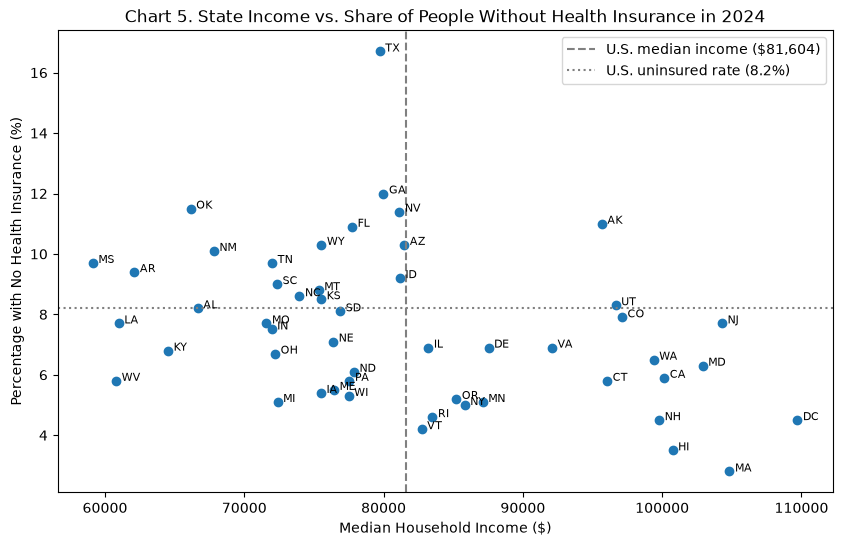

In [49]:
# Chart 5 uses the 50 states + DC (Puerto Rico is left out, see above)
chart_data = final_acs_dataset[final_acs_dataset["state"] != "PR"]

plt.scatter(chart_data["median_hh_income"], chart_data["uninsured_pct"])

# Label each dot with its state code
for i in chart_data.index:
    plt.text(chart_data.loc[i, "median_hh_income"] + 400, chart_data.loc[i, "uninsured_pct"], chart_data.loc[i, "state"], fontsize=8)

# Dashed lines at the U.S. values split the chart into 4 quadrants
plt.axvline(United_States_values["median_hh_income"], color="gray", linestyle="--", label="U.S. median income ($81,604)")
plt.axhline(United_States_values["uninsured_pct"], color="gray", linestyle=":", label="U.S. uninsured rate (8.2%)")

plt.title("Chart 5. State Income vs. Share of People Without Health Insurance in 2024")
plt.xlabel("Median Household Income ($)")
plt.ylabel("Percentage with No Health Insurance (%)")
plt.legend()
plt.show()

**Answer Q3.2:** Based on these tables and the chart, the states to watch are those in the top-left quadrant: below the U.S. median household income and above the U.S. uninsured rate. There are 16 of them, including Texas, Georgia, Oklahoma, Nevada, Florida, Wyoming, Arizona, New Mexico and Kansas. Texas is particularly interesting because it has the highest uninsured rate, at 16.7%.

These results suggest that states with lower median household income tend to have higher uninsured rates. However, the relationship is not a direct one: Alaska and Utah have above-average incomes and above-average uninsured rates, and other factors such as poverty rates, public insurance coverage and commute times vary from state to state. *Caveat:* state averages hide large differences within each state.

**Q3.3 Which states are furthest above or below the U.S. average on income and poverty?**

In [50]:
#The Top 5 States with median household income

highest_five_hh_income = final_acs_dataset[["state_name", "median_hh_income", "state_income_vs_us"]].sort_values("median_hh_income", ascending = False).head(5)

print("The Top 5 States with the highest median household income are:")
display(highest_five_hh_income)

#The bottom 5 states with the lowest median household income

lowest_five_hh_income = final_acs_dataset[["state_name", "median_hh_income", "state_income_vs_us"]].sort_values("median_hh_income").head(5)

print("The Bottom 5 States with the lowest median household income are:")
display(lowest_five_hh_income)

The Top 5 States with the highest median household income are:


,state_name,median_hh_income,state_income_vs_us
8,District of Columbia,109707,28103
21,Massachusetts,104828,23224
30,New Jersey,104294,22690
20,Maryland,102905,21301
11,Hawaii,100745,19141


The Bottom 5 States with the lowest median household income are:


,state_name,median_hh_income,state_income_vs_us
51,Puerto Rico,27213,-54391
24,Mississippi,59127,-22477
48,West Virginia,60798,-20806
18,Louisiana,60986,-20618
3,Arkansas,62106,-19498


In [51]:
#The Top 5 States with the highest poverty rates

highest_five_poverty_rates = final_acs_dataset[["state_name", "poverty_pct", "state_poverty_vs_us"]].sort_values("poverty_pct", ascending=False).head(5)

print("The Top 5 States with the highest poverty rates are:")
display(highest_five_poverty_rates)

#The Bottom 5 States with the lowest poverty rates
lowest_five_poverty_rates = final_acs_dataset[["state_name", "poverty_pct", "state_poverty_vs_us"]].sort_values("poverty_pct").head(5)

print("The Bottom 5 States with the lowest poverty rates are:")
display(lowest_five_poverty_rates)

The Top 5 States with the highest poverty rates are:


,state_name,poverty_pct,state_poverty_vs_us
51,Puerto Rico,37.30,25.20
18,Louisiana,18.70,6.60
24,Mississippi,17.80,5.70
8,District of Columbia,17.30,5.20
48,West Virginia,16.70,4.60


The Bottom 5 States with the lowest poverty rates are:


,state_name,poverty_pct,state_poverty_vs_us
29,New Hampshire,7.20,-4.90
44,Utah,8.30,-3.80
45,Vermont,9.00,-3.10
20,Maryland,9.10,-3.00
30,New Jersey,9.20,-2.90


**Answer Q3.3:** DC has the highest median household income (**$109,707**, $28,103 above the U.S. median), followed by Massachusetts and New Jersey. Among the states, **Mississippi has the lowest ($59,127)**, followed by West Virginia and Louisiana, while Puerto Rico is far lower at $27,213. Poverty follows the same pattern: Louisiana (18.7%) and Mississippi (17.8%) have the highest state poverty rates, and New Hampshire has the lowest (7.2%). The margin-of-error check shows that income estimates are precise (every relative error is 4.25% or less), so these differences are reliable.

**Q3.4 Which states rely most on public health coverage, and which have the longest commutes?**

In [52]:
#The Top 5 States with the highest public insurance rates

highest_five_public_insurance = final_acs_dataset[["state_name", "public_insurance_pct"]].sort_values("public_insurance_pct", ascending=False).head(5)

print("The Top 5 States with the highest public insurance rates are:")
display(highest_five_public_insurance)

#The Bottom 5 States with the lowest public insurance rates
lowest_five_public_insurance = final_acs_dataset[["state_name", "public_insurance_pct"]].sort_values("public_insurance_pct").head(5)

print("The Bottom 5 States with the lowest public insurance rates are:")
display(lowest_five_public_insurance)

The Top 5 States with the highest public insurance rates are:


,state_name,public_insurance_pct
51,Puerto Rico,62.40
31,New Mexico,51.40
48,West Virginia,46.70
18,Louisiana,46.30
32,New York,43.60


The Bottom 5 States with the lowest public insurance rates are:


,state_name,public_insurance_pct
44,Utah,22.20
43,Texas,28.20
34,North Dakota,28.60
16,Kansas,30.60
50,Wyoming,31.20


In [53]:
#The Top 5 States with the longest commute times

longest_top_five_commute_times = final_acs_dataset[["state_name", "commute_min"]].sort_values("commute_min", ascending=False).head(5)

print("The Top 5 States with the longest commute times are:")
display(longest_top_five_commute_times)

#The Bottom 5 States with the shortest commute times
shortest_five_commute_times = final_acs_dataset[["state_name", "commute_min"]].sort_values("commute_min").head(5)

print("The Bottom 5 States with the shortest commute times are:")
display(shortest_five_commute_times)

The Top 5 States with the longest commute times are:


,state_name,commute_min
32,New York,33.20
20,Maryland,32.30
30,New Jersey,31.90
8,District of Columbia,31.00
21,Massachusetts,30.60


The Bottom 5 States with the shortest commute times are:


,state_name,commute_min
34,North Dakota,17.50
41,South Dakota,18.50
26,Montana,19.50
50,Wyoming,19.70
1,Alaska,19.80


**Answer Q3.4:** Public coverage (Medicaid, Medicare and other programs) is highest in **New Mexico (51.4%)**, West Virginia (46.7%) and Louisiana (46.3%), apart from Puerto Rico (62.4%), and lowest in Utah (22.2%). Commutes are longest in **New York (33.2 minutes)**, Maryland and New Jersey, and shortest in **North Dakota (17.5 minutes)**, South Dakota and Montana. The short-commute states are the same rural states that have the fastest EDs in Chart 2.

**Takeaway (Section 3):** The Census table was already complete and passed every validity check, so cleaning mainly meant renaming codes, adding a state key and flagging Puerto Rico. Lower-income states tend to have more uninsured residents, and the rural states with short commutes match the states with the fastest EDs. State income, insurance coverage and rurality are therefore worth testing against ED wait times after the merge.

**Data dictionary: `final_acs_dataset` (key columns; all renamed columns are listed in `census_names` above)**

| Column | Type | Description |
|---|---|---|
| `state` | str | Two-letter state code (merge key) |
| `state_name` | str | Full state name |
| `is_territory` | bool | True for Puerto Rico |
| `median_hh_income` | int | Median household income (USD) |
| `uninsured_pct` | float | Share of people with no health insurance (%) |
| `public_insurance_pct` | float | Share of people with public coverage (%) |
| `poverty_pct` | float | Share of people below the poverty line (%) |
| `commute_min` | float | Average commute time (minutes) |
| `state_..._vs_us` | float | State value minus the U.S. value (income, unemployment, uninsured, poverty) |

---
# Section 4: Combined Dataset
The cleaned tables are joined into one table with one row per hospital. The wait-time table from Section 1 is the base, because a hospital without the main outcome cannot be analyzed.

In [54]:
# Join the hospital characteristics (Section 2) on facility_id
# facility_name, state and is_territory are dropped here because they are already in the other tables
hospital_info = hgi_cleaned.drop(columns=["facility_name", "state", "is_territory"])
final_data = pd.merge(waits_clean, hospital_info, on="facility_id", how="inner")
print("Hospitals after joining Section 2:", len(final_data))

# Join the state economic data (Section 3) on state
final_data = pd.merge(final_data, final_acs_dataset, on="state", how="inner")
print("Hospitals after joining Section 3:", len(final_data))

# Join the ED crowding measures (Section 1.4) on facility_id
# Left join: hospitals without crowding data are kept, with missing values
final_data = pd.merge(final_data, crowding, on="facility_id", how="left")
print("Hospitals after joining the crowding measures:", len(final_data))

Hospitals after joining Section 2: 4081
Hospitals after joining Section 3: 4080
Hospitals after joining the crowding measures: 4080


In [55]:
print(final_data.shape)
final_data.head()

(4080, 76)


,facility_id,facility_name,state,op_18a_min,op_18b_min,op_18c_min,op_18d_min,address,city_town,zip_code,county_parish,hospital_type,hospital_ownership,emergency_services,meets_criteria_for_birthing_friendly_designation,hospital_overall_rating,mort_group_measure_count,count_of_facility_mort_measures,count_of_mort_measures_better,count_of_mort_measures_no_different,count_of_mort_measures_worse,safety_group_measure_count,count_of_facility_safety_measures,count_of_safety_measures_better,count_of_safety_measures_no_different,...,median_hh_income_high,mean_hh_income,social_security_pct,snap_pct,per_capita_income,median_worker_earnings,insured_pct,private_insurance_pct,public_insurance_pct,uninsured_pct,uninsured_pct_moe,uninsured_pct_low,uninsured_pct_high,family_poverty_pct,poverty_pct,child_poverty_pct,senior_poverty_pct,income_relative_to_error_pct,state_income_vs_us,state_unemployment_vs_us,state_uninsured_vs_us,state_poverty_vs_us,edv_level,op_22_left_pct,sep_1_pct
0,010001,SOUTHEAST HEALTH MEDICAL CENTER,AL,214.00,212.00,NaN,NaN,1108 ROSS CLARK CIRCLE,DOTHAN,36301,HOUSTON,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,4,8.00,8.00,0.00,8.00,0.00,8.00,7.00,3.00,4.00,...,67439,90741,34.80,13.10,36940,41871,91.80,67.50,37.90,8.20,0.30,7.90,8.50,10.90,15.20,20.20,13.00,1.17,-14945,-0.40,0.00,3.10,very high,3.00,61.00
1,010005,MARSHALL MEDICAL CENTERS,AL,146.00,143.00,242.00,332.00,2505 U S HIGHWAY 431 NORTH,BOAZ,35957,MARSHALL,Acute Care Hospitals,Government - Hospital District or Authority,Yes,Y,3,8.00,6.00,0.00,5.00,1.00,8.00,7.00,0.00,7.00,...,67439,90741,34.80,13.10,36940,41871,91.80,67.50,37.90,8.20,0.30,7.90,8.50,10.90,15.20,20.20,13.00,1.17,-14945,-0.40,0.00,3.10,very high,3.00,73.00
2,010006,NORTH ALABAMA MEDICAL CENTER,AL,158.00,147.00,218.00,328.00,1701 VETERANS DRIVE,FLORENCE,35630,LAUDERDALE,Acute Care Hospitals,Proprietary,Yes,Y,2,8.00,8.00,0.00,5.00,3.00,8.00,8.00,4.00,4.00,...,67439,90741,34.80,13.10,36940,41871,91.80,67.50,37.90,8.20,0.30,7.90,8.50,10.90,15.20,20.20,13.00,1.17,-14945,-0.40,0.00,3.10,high,1.00,61.00
3,010007,MIZELL MEMORIAL HOSPITAL,AL,137.00,130.00,242.00,295.00,702 N MAIN ST,OPP,36467,COVINGTON,Acute Care Hospitals,Voluntary non-profit - Private,Yes,N,1,8.00,4.00,0.00,3.00,1.00,8.00,2.00,0.00,2.00,...,67439,90741,34.80,13.10,36940,41871,91.80,67.50,37.90,8.20,0.30,7.90,8.50,10.90,15.20,20.20,13.00,1.17,-14945,-0.40,0.00,3.10,low,1.00,33.00
4,010011,ST. VINCENT'S EAST,AL,168.00,158.00,NaN,371.00,50 MEDICAL PARK EAST DRIVE,BIRMINGHAM,35235,JEFFERSON,Acute Care Hospitals,Voluntary non-profit - Private,Yes,N,3,8.00,8.00,0.00,8.00,0.00,8.00,7.00,1.00,6.00,...,67439,90741,34.80,13.10,36940,41871,91.80,67.50,37.90,8.20,0.30,7.90,8.50,10.90,15.20,20.20,13.00,1.17,-14945,-0.40,0.00,3.10,NaN,NaN,70.00


**Takeaway (Section 4):** All 4,081 hospitals from Section 1 matched a record in the hospital table, and one hospital in Guam was dropped because the Census data does not cover Guam. The crowding measures were added with a left join, so every hospital is kept; ED volume is available for 3,772 of them. The final dataset has **4,080 hospitals and 76 columns**, combining wait times, crowding, hospital characteristics and state economic conditions in one row per hospital.

---
# Conclusion
This phase focused on understanding and preparing the data, so the findings below are early observations rather than final conclusions.

**Key insights**
1. **Psychiatric patients wait far longer.** At 92.5% of hospitals, psychiatric patients stay longer than other patients (median gap: 83 minutes). *Action:* hospitals should review behavioral health capacity and transfer pathways. *Impact: High · Feasibility: Medium.*
2. **Location is strongly associated with wait time.** Median visit times range from 105 minutes (ND) to 328 minutes (DC). *Next:* test whether hospital size, type and state economics explain this gap. *Impact: Medium · Feasibility: High.*
3. **Rurality appears in every dataset.** The states with the fastest EDs (ND, SD, NE, MT) have the highest share of Critical Access hospitals (64–79%) and the shortest commutes, while several of the slowest (DC, MD, DE, RI) have none. *Next:* test hospital type and state rurality against `OP_18b` using the combined dataset. *Impact: High · Feasibility: High.*
4. **For-profit and government hospitals receive lower star ratings.** Only 28.7% of rated for-profit hospitals have 4–5 stars, compared with 45.7% of non-profit hospitals. *Next:* check whether lower-rated owners also have longer ED waits. *Impact: Medium · Feasibility: High.*
5. **Busier EDs lose more patients before they are seen.** An average of 2.31% of patients leave very-high-volume EDs before being seen, compared with 1.08% at low-volume EDs. *Next:* test whether ED volume also explains longer `OP_18b` wait times. *Impact: High · Feasibility: High.*

**Risks and limitations**
- Values are hospital-level medians, not individual patient waits.
- Measures cover different time windows (2024 for crowding measures; Oct 2024 to Sep 2025 for wait times).
- Missing data is not random: small and low-volume hospitals report less often.
- State averages hide large differences within each state.
- The analysis is descriptive and does not establish cause and effect.

**Next steps**
- Use the combined dataset (Section 4) as the base table for the final analysis.
- Compare wait times across ownership, hospital type, star rating, ED volume and state economic conditions.
- Examine correlations between wait times and the state-level economic indicators.

# References
1. Centers for Medicare & Medicaid Services. (2025). *Timely and effective care – Hospital* [Data set]. https://data.cms.gov/provider-data/dataset/yv7e-xc69
2. Centers for Medicare & Medicaid Services. (2025). *Hospital general information* [Data set]. https://data.cms.gov/provider-data/dataset/xubh-q36u
3. U.S. Census Bureau. (2025). *Selected economic characteristics, American Community Survey 1-year estimates, Table DP03, 2024* [Data set]. https://data.census.gov/table/ACSDP1Y2024.DP03?g=010XX00US$0400000
4. Centers for Medicare & Medicaid Services. (2025). *Hospital data dictionary* (measure definitions and footnotes). https://data.cms.gov/provider-data/sites/default/files/data_dictionaries/hospital/HOSPITAL_Data_Dictionary.pdf
5. Cohort A, Team 4. (2026). *ba780-er-wait-times* [GitHub repository with copies of the three datasets]. https://github.com/Hassan02052002/ba780-er-wait-times
6. Python libraries: pandas, NumPy and Matplotlib (versions printed in the Setup cell).

# Generative AI Disclosure
**Project organization.** Hassan, as the team's project manager, led the main idea for the project and divided the work into four parts (ED wait times, hospital characteristics, state economic conditions and ED crowding) so that each of the four team members could clean and explore one part in parallel and the team could reach its results efficiently. The team set the research question, made the final cleaning decisions (for example, the 24-hour limit on median stays and leaving missing values unfilled) and decided how to interpret the results.

**How AI was used.** We used generative AI tools as assistants for specific tasks rather than to produce the analysis as a whole:
- **Planning:** Claude (Anthropic) was used at the start to review the three datasets and to brainstorm the notebook layout and exploratory questions.
- **Loading data and cleaning syntax:** Claude and ChatGPT helped with pandas syntax for loading and cleaning (Sections 1,2 and 3), including the state-code dictionary and the final column list in Section 3.
- **Markdown Cells:** We used Claude to generate most of the final markdown cells with clear and concise language to let the reader know the structure of the notebook + every sub section
- **ED crowding:** OpenAI Codex produced a first version of the crowding analysis, which was simplified and incorporated into Section 1.4.
- **Visualization code:** AI tools helped with chart code such as labels, colors and layout.

**How we checked the output.** AI-generated code was not used as-is. In several cases the generated code did not produce the chart we had in mind, so we adjusted it. Every number in the written answers was checked against the code outputs, and the full notebook was run from top to bottom with Restart & Run All.